# Lab 06：在 CPU 上預訓練一個 500 萬參數的 GPT

對應講義：[第 06 課](../lessons/06_pretraining.md)

1. 準備資料：課程 tokenizer（Lab 03）切好的 TinyStories
2. 開訓前的檢查：初始 loss ≈ $\ln|V|$
3. 主訓練：nanochat 風格的 4 層模型、Muon ＋ AdamW、WSD 排程（式 6.4），約 27 分鐘
4. 評估：驗證 loss、bits-per-byte，和 n-gram（Lab 01）、GPT-2（Lab 05）比較；生成故事
5. 小規模比較：GPT-2 架構 vs nanochat 架構、AdamW vs Muon

**這裡存下的 `checkpoints/base_model.pt` 會被 Lab 09、11、12、13 使用。**
CPU 約 40 分鐘（主訓練約 27 分鐘，§5 的三個短訓練約 12 分鐘）。

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import count_parameters, get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}, {torch.get_num_threads()} threads")

torch 2.14.0+cu130 on cpu, 4 threads


## 1. 資料

In [2]:
from lm_course.artifacts import course_tokenizer, course_tokens

tok = course_tokenizer()  # trained and saved by lab 03 (or trained here on first use)
train_tokens, val_tokens = course_tokens(tok)
token_bytes = torch.tensor(tok.token_byte_lengths())
print(f"vocabulary {tok.vocab_size}; {len(train_tokens):,} training tokens, {len(val_tokens):,} validation tokens")
print(f"bytes per token (training): {token_bytes[torch.from_numpy(train_tokens.astype(np.int64))].sum().item() / len(train_tokens):.2f}")
print("a window of training data:", repr(tok.decode(train_tokens[1000:1060].tolist())))

vocabulary 4096; 4,927,886 training tokens, 550,777 validation tokens
bytes per token (training): 4.03
a window of training data: ' morning sun. They both felt very happy. They decided to play together and have fun all day.\nAt the end of the day, Tom and Max were tired. They had played all day and had lots of fun. They said goodbye to each other and went to their homes. Before going to'


## 2. 模型與開訓前的檢查

`base_model_config()`：nanochat 風格（無參數 RMSNorm、RoPE、ReLU²、QK-norm、不綁 embedding、logit soft-cap 15），4 層、寬 256、4 個 head、context 256。
初始化照 GPT-2（std 0.02），所以初始 logits 很小、分布接近均勻，loss 應接近 $\ln 4096 = 8.318$。

In [3]:
from lm_course.artifacts import base_model_config
from lm_course.model import GPT, parameter_summary
from lm_course.training import lm_loss, random_batch

config = base_model_config()
model = GPT(config).to(device)
summary = parameter_summary(model)
print(config)
print(f"{summary.total:,} parameters ({summary.non_embedding:,} non-embedding)")
x, y = random_batch(train_tokens, 32, config.context_length, np.random.default_rng(0), device)
with torch.no_grad():
    print(f"initial loss {lm_loss(model(x), y).item():.3f}   (ln 4096 = {math.log(4096):.3f})")

GPTConfig(vocab_size=4096, context_length=256, n_layer=4, n_head=4, d_model=256, n_kv_head=None, d_ff=None, norm='rmsnorm', norm_affine=False, position='rope', rope_base=10000.0, mlp='relu2', bias=False, tie_embeddings=False, qk_norm=True, logit_softcap=15.0, causal=True, norm_eps=1e-05)
5,242,880 parameters (4,194,304 non-embedding)


initial loss 8.320   (ln 4096 = 8.318)


## 3. 主訓練

- Muon（lr 0.02）更新區塊內的矩陣；AdamW（lr 3e-3、$\beta = (0.9, 0.95)$、weight decay 0.1）更新 embedding、LM head；向量參數不 decay。
- WSD：暖身 50 步，最後 40% 的步數線性降到 0。
- 1,500 步 × 32 個視窗 × 256 token ≈ 1,230 萬 token，約是訓練資料的 2.5 倍（講義 §2.1）。

In [4]:
from lm_course.optim import build_optimizer, wsd_schedule
from lm_course.training import train

STEPS = 1500
optimizer = build_optimizer(model, "muon", lr=3e-3, muon_lr=0.02)
result = train(
    model,
    train_tokens,
    val_tokens,
    num_steps=STEPS,
    batch_size=32,
    optimizer=optimizer,
    schedule=wsd_schedule,
    warmup=50,
    eval_every=100,
    eval_batches=10,
    log_every=250,
)
print(f"trained on {result.tokens_seen:,} tokens in {result.seconds / 60:.1f} min ({result.tokens_seen / result.seconds:,.0f} tokens/s)")

step   250/1500: loss 2.870, val 2.868 (277s)


step   500/1500: loss 2.329, val 2.449 (554s)


step   750/1500: loss 2.266, val 2.308 (826s)


step  1000/1500: loss 1.979, val 2.174 (1101s)


step  1250/1500: loss 1.804, val 2.080 (1372s)


step  1500/1500: loss 1.784, val 1.986 (1644s)


trained on 12,288,000 tokens in 27.4 min (7,475 tokens/s)


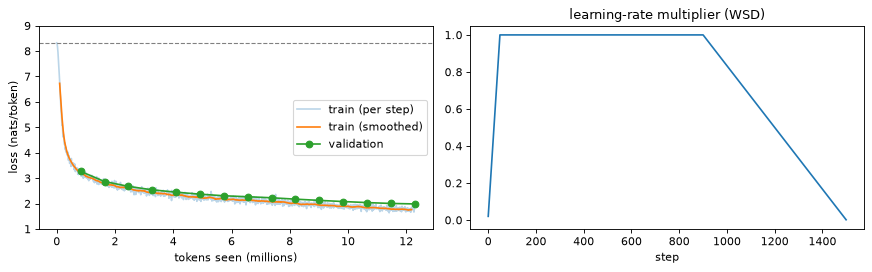

In [5]:
def smooth(values: list[float], window: int = 25) -> np.ndarray:
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

tokens_per_step = 32 * config.context_length
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(np.arange(len(result.losses)) * tokens_per_step / 1e6, result.losses, alpha=0.3, label="train (per step)")
axes[0].plot((np.arange(len(smooth(result.losses))) + 12) * tokens_per_step / 1e6, smooth(result.losses), label="train (smoothed)")
axes[0].plot(np.array(result.eval_steps) * tokens_per_step / 1e6, result.eval_losses, "o-", label="validation")
axes[0].axhline(math.log(4096), color="gray", ls="--", lw=1)
axes[0].set_xlabel("tokens seen (millions)")
axes[0].set_ylabel("loss (nats/token)")
axes[0].set_ylim(1, 9)
axes[0].legend()
axes[1].plot([wsd_schedule(s, STEPS, 50) for s in range(STEPS)])
axes[1].set_xlabel("step")
axes[1].set_title("learning-rate multiplier (WSD)")
plt.tight_layout()
plt.show()

讀曲線（講義 §2.7）：前幾十步從 $\ln|V|$ 急降到 unigram 的程度，之後穩定下降；訓練與驗證 loss 很接近（資料只看了約 2.5 遍，還沒開始背）。最後 40% 是學習率遞減段（warmdown），但在這條曲線上看不出明顯的轉折——遞減段的好處要和「不降學習率」的曲線比才量得出來（講義練習 9）。

## 4. 評估與存檔

In [6]:
from lm_course.artifacts import BASE_MODEL_PATH
from lm_course.model import save_model
from lm_course.training import evaluate

final = evaluate(model, val_tokens, config.context_length, batch_size=32, max_batches=40, token_bytes=token_bytes)
print(f"validation: {final.loss:.3f} nats/token, perplexity {final.perplexity:.1f}, {final.bits_per_byte:.3f} bits/byte")
save_model(model, BASE_MODEL_PATH, val_loss=final.loss, bits_per_byte=final.bits_per_byte)
print(f"saved checkpoints/{BASE_MODEL_PATH.name}")

validation: 1.967 nats/token, perplexity 7.1, 0.705 bits/byte
saved checkpoints/base_model.pt


bits-per-byte 可以跨 tokenizer 比較（第 01 課式 1.4）。同一份驗證故事上：

| 模型 | 驗證 bits/byte | 出處 |
|---|---|---|
| 均勻分布 | 8.000 | — |
| 最好的 byte n-gram（Witten–Bell 插值，$n = 9$） | 1.240 | Lab 01 §4；數數 |
| GPT-2 124M（零樣本） | 0.872 | Lab 05 §3；在 WebText 上訓練，沒看過 TinyStories |
| **本模型（5.2M）** | **0.705** | 在 TinyStories 上訓練 27 分鐘 |

### 生成故事

In [7]:
from lm_course.sampling import generate

bos = tok.special_id("<|bos|>")
prompts = ["Once upon a time", "Tom and his dog", "The little girl was sad because"]
g = torch.Generator().manual_seed(0)
for prompt in prompts:
    out = generate(model, [bos] + tok.encode(prompt), 120, temperature=0.8, top_k=50, stop_tokens={bos}, generator=g)[0]
    print(f"--- {prompt} ---")
    print(prompt + tok.decode([t for t in out if t != bos]))
    print()

--- Once upon a time ---
Once upon a time, there was a little boy named Timmy. Timmy loved to play outside in his favorite spot every day. One day, he was playing hide and seek with his friends. They were having a lot of fun.
Suddenly, Timmy found a big, round, round thing in the field. He wanted to keep it, but he didn't know how to play a game. So, he asked his friend, Sam, to help him. Sam said, "Okay, it is just the way to play!"
Timmy and Sam tried to find the orange thing. Suddenly, a little bird flew down from the



--- Tom and his dog ---
Tom and his dog, Spot and Max were playing in the park. They saw a big tree with a long branch. Tom said, "Let's sit next to the tree and look at the branch!" Max barked and wagged his tail. They both sat down and watched the birds play.
But then, something unexpected happened! The branch started to shake and wobble. It was not a tree, but a parkha. Tom and Max were scared. They didn't know what to do. They picked up the branch and ran away.
The tree shook and the leaves fell down. Tom and Max were sad



--- The little girl was sad because ---
The little girl was sad because she didn't feel well. She was sad and her mommy said, "Don't worry, I will help you. We have a special dream to dream about helping you."
The little girl thought for a moment, then said, "It's okay, Mommy. I will keep you safe soon."
The little girl felt much better. She knew she was going to help her mommy with the special moon. She knew that helping Mommy was able to keep the world safe from the park.
The moral of the story is that even when you are scared, it can help you feel better. Even though it



## 5. 小規模比較：架構與最佳化器

同樣的資料順序、同樣的 250 步（約 200 萬 token），比較三種組合的驗證 loss：

1. GPT-2 架構（LayerNorm、learned position、GELU、bias、綁定 embedding）＋ AdamW
2. nanochat 架構 ＋ AdamW
3. nanochat 架構 ＋ Muon（和主訓練相同的設定）

**解讀要小心**：只有一個亂數種子、只訓練 250 步，差距小於約 0.05 的都可能是雜訊；講義 §4 提醒過，多數架構改動的價值要在大規模才看得出來。

In [8]:
from lm_course.model import gpt2_config

SHORT = 250
variants = {
    "GPT-2 + AdamW": (gpt2_config("gpt2", vocab_size=tok.vocab_size, context_length=256, n_layer=4, n_head=4, d_model=256), "adamw"),
    "nanochat + AdamW": (base_model_config(), "adamw"),
    "nanochat + Muon": (base_model_config(), "muon"),
}
curves = {}
for name, (cfg, kind) in variants.items():
    set_seed(0)
    m = GPT(cfg).to(device)
    opt = build_optimizer(m, kind, lr=3e-3, muon_lr=0.02)
    r = train(m, train_tokens, val_tokens, num_steps=SHORT, batch_size=32, optimizer=opt, schedule=wsd_schedule,
              warmup=50, eval_every=50, eval_batches=10, log_every=0)
    curves[name] = r
    print(f"{name:<18} {m.num_parameters():>10,} params  final val loss {r.final_eval_loss:.3f}  ({r.seconds / 60:.1f} min)")

GPT-2 + AdamW       4,273,664 params  final val loss 3.193  (3.2 min)


nanochat + AdamW    5,242,880 params  final val loss 2.845  (4.3 min)


nanochat + Muon     5,242,880 params  final val loss 2.707  (4.7 min)


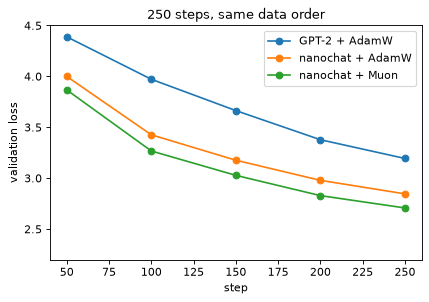

In [9]:
plt.figure(figsize=(6, 3.8))
for name, r in curves.items():
    plt.plot(r.eval_steps, r.eval_losses, "o-", label=name)
plt.xlabel("step")
plt.ylabel("validation loss")
plt.ylim(2.2, 4.5)
plt.legend()
plt.title("250 steps, same data order")
plt.show()

三條曲線從頭到尾沒有交叉，250 步時的差距（約 0.35 與 0.14）也遠大於 0.05。但要注意兩件事：GPT-2 變體綁定了 embedding，少了約 100 萬參數；三者都沿用替 nanochat 設定挑的學習率，沒有替 GPT-2 架構或 AdamW 另外調。所以能說的只是「在這個設定、這麼短的訓練下」，nanochat 的組合學得比較快。

## 小結

- 5.2M 參數的模型在 CPU 上訓練約 27 分鐘，就能寫出文法大致正確的幼兒故事；它在 TinyStories 上的 bits-per-byte（0.705）比 24 倍大、但沒看過 TinyStories 的 GPT-2（0.872）還低——專才勝過通才。
- 開訓前先檢查初始 loss；loss 曲線的最後一段遞減來自學習率的 warmdown。
- 短訓練的比較請看趨勢、別看小數點：真正的結論需要多個種子與更大的規模（第 07 課）。

下一步：[第 07 課](../lessons/07_scaling_laws.md)——給定算力，模型該多大、資料該多少？